<a href="https://colab.research.google.com/github/ropdxm/dimash-qurt-classifier/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.1 MB/s eta 0:00:00
Mounted at /content/gdrive


In [3]:
from fastbook import *
from fastai.vision.widgets import *
import os

In [4]:
from fastai.vision.all import *

In [5]:
!  pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 65.3 MB/s eta 0:00:00


In [11]:
dimash_queries = [
    "Dimash Kudaibergen face",
    "Dimash Qudaibergen portrait",
    "Dimash Kudaibergen interview close-up",
    "Димаш Кудайберген фото",
    "Димаш Құдайберген портрет",
]

qurt_queries = [
    "qurt kazakh snack",
    "kazakh qurt food",
    "qurut dried yogurt balls",
    "kurut snack central asia",
    "құрт тағам",
    "құрт қазақша",
    "курт казахский продукт",
]

In [15]:
!pip -q install -U ddgs

from ddgs import DDGS
from ddgs.exceptions import DDGSException
from time import sleep

def ddgs_images_retry(query, max_results=100, tries=3, pause_base=3):
    """
    Runs DDGS image search with retry/backoff.
    Returns a list of image URLs.
    """
    for attempt in range(tries):
        try:
            with DDGS(timeout=20) as ddgs:
                results = list(ddgs.images(query, max_results=max_results))
                urls = [r["image"] for r in results if isinstance(r, dict) and r.get("image")]
                if urls:
                    return urls
        except DDGSException as e:
            print(f"Attempt {attempt+1}/{tries} failed for '{query}' -> {e}")
        except Exception as e:
            print(f"Attempt {attempt+1}/{tries} failed for '{query}' -> {type(e).__name__}: {e}")

        sleep(pause_base * (attempt + 1))

    print(f"DDGS failed for query: {query} -> No usable results.")
    return []

def normalize_url(url):
    # Strip query params so duplicates are easier to catch
    return url.split("?")[0].strip()

def unique_urls(urls):
    seen = set()
    out = []
    for u in urls:
        if not u:
            continue
        key = normalize_url(u)
        if key not in seen:
            seen.add(key)
            out.append(u)
    return out

def save_urls(urls, out_file):
    out_file = Path(out_file)
    out_file.write_text(json.dumps(urls, indent=2, ensure_ascii=False), encoding="utf-8")

def load_urls(in_file):
    in_file = Path(in_file)
    if not in_file.exists():
        return []
    return json.loads(in_file.read_text(encoding="utf-8"))

def collect_urls_for_class(class_name, queries, target=300, per_query=100):
    """
    Collects URLs across many queries until target is reached.
    Saves progress after each query.
    """
    url_file = BASE_PATH / f"{class_name}_urls.json"
    urls = load_urls(url_file)
    urls = unique_urls(urls)

    print(f"\n=== Collecting URLs for {class_name} ===")
    print(f"Starting with {len(urls)} existing URLs")

    # Shuffle queries a bit to vary request order
    queries = list(queries)
    random.shuffle(queries)

    for q in queries:
        if len(urls) >= target:
            break

        new_urls = ddgs_images_retry(
            q,
            max_results=per_query,
            tries=DDGS_TRIES
        )

        urls.extend(new_urls)
        urls = unique_urls(urls)

        save_urls(urls, url_file)
        print(f"{len(urls):4d} urls after: {q}")

        sleep(PAUSE_BETWEEN_QUERIES)

    print(f"Finished {class_name}: {len(urls)} unique URLs")
    return urls[:target]

def download_class_images(class_name, urls, path):
    """
    Downloads images into BASE_PATH/class_name
    """
    class_path = path / class_name
    class_path.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Downloading {class_name} images ===")
    download_images(class_path, urls=urls, max_pics=len(urls), preserve_filename=False)
    return class_path

def remove_broken_images(folder):
    """
    Removes unreadable/broken image files from a folder.
    """
    files = get_image_files(folder)
    failed = verify_images(files)

    if len(failed):
        print(f"Removing {len(failed)} broken images from {folder.name}")
        for f in failed:
            try:
                f.unlink()
            except Exception as e:
                print(f"Could not remove {f}: {e}")
    else:
        print(f"No broken images found in {folder.name}")

def print_counts():
    print("\n=== Final counts ===")
    for cls in ["dimash", "qurt", "other"]:
        folder = BASE_PATH / cls
        if folder.exists():
            print(f"{cls:>8}: {len(get_image_files(folder))}")



In [16]:

TARGET_PER_CLASS = 350
MAX_RESULTS_PER_QUERY = 120
PAUSE_BETWEEN_QUERIES = 2.5
DDGS_TRIES = 3

dimash_urls = collect_urls_for_class(
    "dimash",
    dimash_queries,
    target=TARGET_PER_CLASS,
    per_query=MAX_RESULTS_PER_QUERY
)

qurt_urls = collect_urls_for_class(
    "qurt",
    qurt_queries,
    target=TARGET_PER_CLASS,
    per_query=MAX_RESULTS_PER_QUERY
)

len(dimash_urls), len(qurt_urls)


=== Collecting URLs for dimash ===
Starting with 329 existing URLs
Attempt 1/3 failed for 'Dimash Qudaibergen portrait' -> No results found.
 329 urls after: Dimash Qudaibergen portrait
 369 urls after: Dimash Kudaibergen interview close-up
Finished dimash: 369 unique URLs

=== Collecting URLs for qurt ===
Starting with 443 existing URLs
Finished qurt: 443 unique URLs


(350, 350)

In [18]:
path = Path("data_dimash_qurt")
(path/"dimash").mkdir(parents=True, exist_ok=True)
(path/"qurt").mkdir(parents=True, exist_ok=True)

dimash_path = download_class_images("dimash", dimash_urls, path)
qurt_path   = download_class_images("qurt", qurt_urls, path)

# =========================
# 7) Remove broken files
# =========================
remove_broken_images(dimash_path)
remove_broken_images(qurt_path)

# =========================
# 8) Show final counts
# =========================
print_counts()


=== Downloading dimash images ===

=== Downloading qurt images ===
Removing 3 broken images from dimash
Removing 1 broken images from qurt

=== Final counts ===
  dimash: 662
    qurt: 622


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
dls = ImageDataLoaders.from_folder(
    path,
    train='.',
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=1.0)
)

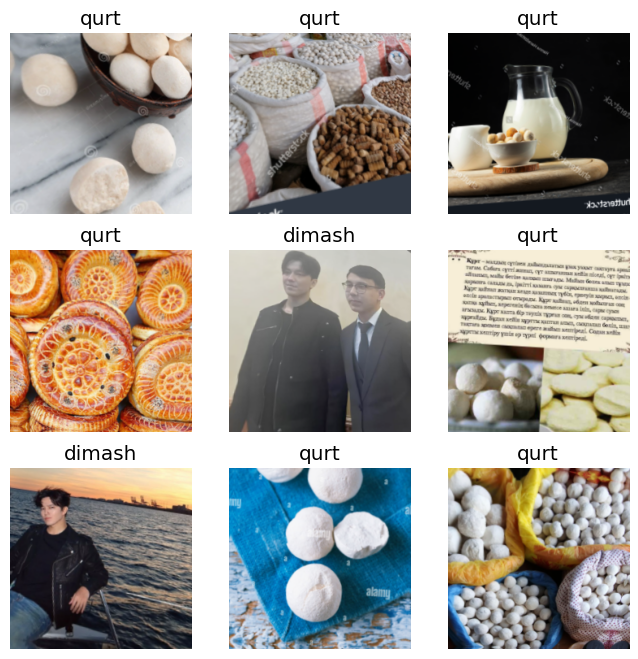

In [21]:
dls.show_batch(max_n=9, figsize=(8,8))

In [22]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.511800,0.059695,0.976562,00:23


epoch,train_loss,valid_loss,accuracy,time
0,0.080263,0.021910,0.992188,00:21
1,0.054673,0.000975,1.000000,00:22
2,0.043984,0.007152,0.996094,00:21
3,0.030048,0.000379,1.000000,00:22
4,0.026873,0.000210,1.000000,00:21


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

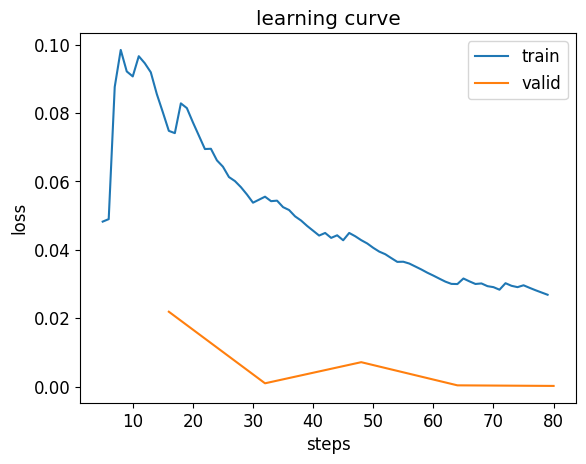

In [23]:
learn.recorder.plot_loss()

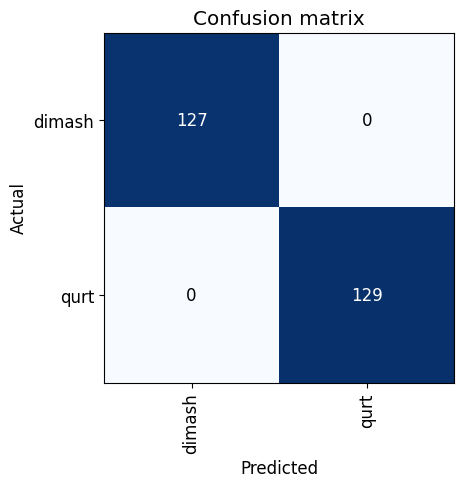

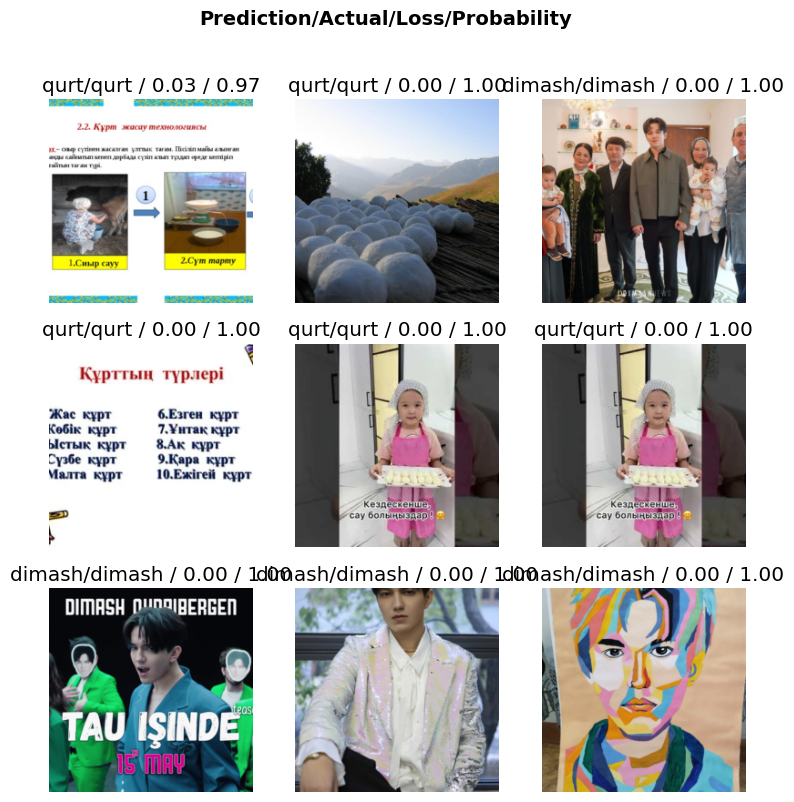

In [24]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, nrows=3)

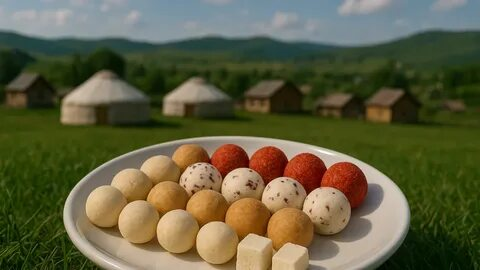

In [28]:
import requests

# image URL from the web
url = "https://avatars.mds.yandex.net/i?id=534091866272147db548991c5bfff54b3cffa8d5-17444072-images-thumbs&n=13"

# where to save it
img_path = Path("/content/test_image.jpg")

# download the image
r = requests.get(url, timeout=30)
r.raise_for_status()
img_path.write_bytes(r.content)

# open and display
img = PILImage.create(img_path)
img

In [29]:
pred, pred_idx, probs = learn.predict(img)

print("Prediction:", pred)
print("Pred index:", pred_idx)
print("Probabilities:")
for label, p in zip(learn.dls.vocab, probs):
    print(f"  {label}: {float(p):.4f}")

Prediction: qurt
Pred index: tensor(1)
Probabilities:
  dimash: 0.0000
  qurt: 1.0000


problem: overfitting